In [ ]:
## Final Update
## This notebook contains the code to fine-tune baseline denoising model from  the first and second update
## Author: Saiful
## Email: mislam5@nd.edu

In [ ]:
!pip install torch torchaudio librosa soundfile pesq matplotlib --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 110.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Final Update - Improvement Strategy

- In Part 3, we trained our model on a dataset created by adding synthetic noise to the clean dataset.
- In Part 4, we fine-tuned that baseline model with additional dataset created by adding real road noise and exhaust fan noise.
-  The code for this data pre-processing is located in a separate notebook named `data_pre_processing.ipynb`.

- In this step we further fine-tuned with with more real world noise samples

## Build a single manifest and stratified splits
- We will build a single manifest file that contains all the data we have used so far.
- We will also create a stratified split of the data into train, validation and test sets.

In [ ]:
import glob, pandas as pd, os, random, pathlib

BASE = "/content/drive/MyDrive/colab-data/audio-denoising"
SYN_CLEAN = f"{BASE}/data/two-sec-sample/clean/*.flac"
RMX_CLEAN = f"{BASE}/data/two-sec-realmix/clean/*.flac"

SEGMENT_MANIFEST = f"{BASE}/segment_manifest.csv"

rows = []
for p in glob.glob(SYN_CLEAN):
    fname = os.path.basename(p)
    rows.append({"clean": p,
                 "noisy": p.replace("/clean/","/noisy/"),
                 "src": "syn"})
for p in glob.glob(RMX_CLEAN):
    fname = os.path.basename(p)
    rows.append({"clean": p,
                 "noisy": p.replace("/clean/","/noisy/"),
                 "src": "rmx"})

df = pd.DataFrame(rows)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)   # shuffle
# stratified split 70‑15‑15 on src
train, val, test = [], [], []
for src in ["syn","rmx"]:
    part = df[df.src==src]
    n = len(part)
    train += part.iloc[:int(0.7*n)].index.tolist()
    val   += part.iloc[int(0.7*n):int(0.85*n)].index.tolist()
    test  += part.iloc[int(0.85*n):].index.tolist()

df.loc[train,"split"] = "train"
df.loc[val,  "split"] = "val"
df.loc[test, "split"] = "test"


# df.to_csv(SEGMENT_MANIFEST, index=False)
print(df.split.value_counts())

split
train    11836
test      2538
val       2536
Name: count, dtype: int64


## Imports and Model Definition
We will use the same imports and model definition as in the previous steps.

In [ ]:
import os
import numpy as np
import librosa
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from IPython.display import Audio, display
from tqdm import tqdm

class DenoisignUNet(nn.Module):

    def __init__(self):
        super().__init__()
        # Add comment

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 3, padding=1), nn.LeakyReLU(0.2)
        )
        self.pool1 = nn.MaxPool2d(kernel_size=(1,2))

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1), nn.LeakyReLU(0.2)
        )
        self.pool2 = nn.MaxPool2d(kernel_size=(1,2))

        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1), nn.LeakyReLU(0.2),
        )

        self.up2 = nn.Conv2d(128, 64, 1)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64+64, 64, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1), nn.LeakyReLU(0.2),
        )

        self.up1 = nn.Conv2d(64, 32, 1)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32+32, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 32, 3, padding=1), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        u2_up = F.interpolate(u2, size=(e2.shape[2], e2.shape[3]), mode='nearest')
        d2 = self.dec2(torch.cat([u2_up, e2], dim=1))

        u1 = self.up1(d2)
        u1_up = F.interpolate(u1, size=(e1.shape[2], e1.shape[3]), mode='nearest')
        d1 = self.dec1(torch.cat([u1_up, e1], dim=1))
        return d1


In [ ]:
BASE = "/content/drive/MyDrive/colab-data/audio-denoising"
MANIFEST = f"{BASE}/segment_manifest.csv"
MODEL_PRE = f"{BASE}/models/model_2s_10_epoch.pth"
PARAMS_PRE= f"{BASE}/models/model_2s_10_epoch_params.json"

class Cfg:
    sr = 16000
    n_fft = 512; hop = 128; win = 512
    seg_len = 32000          # 2 s
    batch  = 16
    lr_ft  = 2e-5            # fine‑tune LR
    epochs = 20

### Custom Dataset Class

Defines a PyTorch dataset class (`SegDataset`) to:
- Load audio files.
- Compute and normalize spectrograms and saves in json file (`train_stats.json`) for reuse
- Handle training, validation, and test splits.

In [ ]:
import json
import glob, pandas as pd, os, random, pathlib

def stft2logmag(y, cfg):
    D = librosa.stft(y, n_fft=cfg.n_fft, hop_length=cfg.hop, win_length=cfg.win)
    return np.log1p(np.abs(D))

class SegDataset(Dataset):
    def __init__(self, csv_path, split, cfg, gmin=None, gmax=None, load_train_stats = True):
        self.meta = pd.read_csv(csv_path).query(f"split=='{split}'").reset_index(drop=True)
        self.cfg  = cfg
        if split=="train":
            if load_train_stats:
                print("Loading pre‑computed stats")
                stats = json.load(open(f"{BASE}/train_stats.json"))
                self.gmin, self.gmax = stats["gmin"], stats["gmax"]
            else:
              mags = []
              for i in random.sample(range(len(self.meta)), k=min(400, len(self.meta))):
                  c,_ = librosa.load(self.meta.clean[i], sr=cfg.sr)
                  n,_ = librosa.load(self.meta.noisy[i], sr=cfg.sr)
                  mags += [stft2logmag(c, cfg), stft2logmag(n, cfg)]
              flat = np.concatenate([x.flatten() for x in mags])
              self.gmin, self.gmax = float(flat.min()), float(flat.max())
              json.dump({"gmin":self.gmin,"gmax":self.gmax},
                        open(f"{BASE}/train_stats.json","w"))
        else:
            stats = json.load(open(f"{BASE}/train_stats.json"))
            self.gmin, self.gmax = stats["gmin"], stats["gmax"]

    def __len__(self): return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        c, _ = librosa.load(row.clean, sr=self.cfg.sr)
        n, _ = librosa.load(row.noisy, sr=self.cfg.sr)
        cm, nm = stft2logmag(c,self.cfg), stft2logmag(n,self.cfg)
        cm = (cm-self.gmin)/(self.gmax-self.gmin); nm = (nm-self.gmin)/(self.gmax-self.gmin)
        return dict(clean=torch.from_numpy(c),
                    noisy=torch.from_numpy(n),
                    cm=torch.from_numpy(cm)[None],
                    nm=torch.from_numpy(nm)[None])

### Load Pre-Trained Model
Loads the pre-trained U-Net model onto the available device (GPU or CPU) and sets it to evaluation mode.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using", device)
net = DenoisignUNet().to(device)
net.load_state_dict(torch.load(MODEL_PRE, map_location=device))
net.eval()
print("Loaded pre‑trained weights")

Using cuda
Loaded pre‑trained weights


## Fine-tuning

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Fine‑tune with verbose logging + audio demo every 3 epochs
# ──────────────────────────────────────────────────────────────────────
from pesq import pesq
from IPython.display import Audio, display
import torch.nn.functional as F
import numpy as np, librosa, torch, json, os
from torch.utils.data import DataLoader
from tqdm import tqdm
import glob, pandas as pd, os, random, pathlib

# ---------- helpers ----------
def stft2logmag(y, cfg):
    return np.log1p(np.abs(librosa.stft(y,
                       n_fft=cfg.n_fft, hop_length=cfg.hop, win_length=cfg.win)))

def nm2wav(nm, phase, cfg, gmin, gmax):
    mag = np.expm1(nm*(gmax-gmin)+gmin)
    st  = mag * np.exp(1j*phase)
    return librosa.istft(st, hop_length=cfg.hop, win_length=cfg.win, length=cfg.seg_len)

# ---------- data ----------
train_ds = SegDataset(MANIFEST, "train", Cfg)  # computes & saves gmin/gmax
val_ds   = SegDataset(MANIFEST, "val",   Cfg)  # reuses the same gmin/gmax
train_ld = DataLoader(train_ds, batch_size=Cfg.batch, shuffle=True,  drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=Cfg.batch, shuffle=False, drop_last=False)

Loading pre‑computed stats


### Fine-Tuning Loop
Implements the fine-tuning loop with:
- Mixed precision training for efficiency.
- Spectrogram and waveform loss computation.
- Early stopping based on PESQ scores.
- Periodic validation and model checkpointing.

In [ ]:
!pip install pesq pystoi --quiet

In [ ]:
# ----------------------------------------------------------------------------------
# FAST & ACCURATE FINE‑TUNE LOOP  (variable names / paths unchanged)
# ----------------------------------------------------------------------------------
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F
import numpy as np, librosa, torch, time, os
from pesq import pesq
from IPython.display import Audio, display

# ─── DataLoaders ────────────────────────────────────────────────────
train_ld = DataLoader(train_ds, batch_size=Cfg.batch, shuffle=True,
                      num_workers=4, pin_memory=True, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=Cfg.batch, shuffle=False,
                      num_workers=2, pin_memory=True, drop_last=False)

# ─── Demo clip (same logic, safe fallback) ─────────────────────────
demo_idx = 10 if len(val_ds) > 10 else 0
demo_row = val_ds.meta.iloc[demo_idx]
demo_clean,_ = librosa.load(demo_row.clean, sr=Cfg.sr)
demo_noisy,_ = librosa.load(demo_row.noisy, sr=Cfg.sr)
demo_phase = np.angle(librosa.stft(demo_noisy, n_fft=Cfg.n_fft,
                                   hop_length=Cfg.hop, win_length=Cfg.win))

# ─── Model + optimiser + AMP ───────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
net = DenoisignUNet().to(device)
net.load_state_dict(torch.load(os.path.join(BASE,"models","model_2s_10_epoch.pth"),
                               map_location=device))
opt    = torch.optim.Adam(net.parameters(), lr=Cfg.lr_ft)
scaler = GradScaler()

print("GPU :", torch.cuda.get_device_name(0))
print("Train segments:", len(train_ds))

# ─── Hann window cached on GPU  (avoids warning + speeds ISTFT) ────
win_t = torch.hann_window(Cfg.win, device=device)

# ─── GPU STFT / ISTFT helpers  (single call, no CPU fallback) ──────
def stft_gpu(x):
    return torch.stft(x, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                      win_length=Cfg.win, window=win_t,
                      return_complex=True)

def istft_gpu(X):
    return torch.istft(X, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                       win_length=Cfg.win, window=win_t,
                       length=Cfg.seg_len)

# ─── quick val PESQ on 100 segments ────────────────────────────────
def quick_val_pesq(net, max_seg=100):
    net.eval(); pesqs=[]; done=0
    with torch.no_grad():
        for b in tqdm(val_ld, total=int(np.ceil(max_seg/Cfg.batch)),
                      desc="val‑PESQ", leave=False):
            out = net(b["nm"].to(device, non_blocking=True)).float().cpu()
            for k in range(out.size(0)):
                if done >= max_seg: return np.mean(pesqs)
                ph  = np.angle(librosa.stft(b["noisy"][k].numpy(),
                                            n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                                            win_length=Cfg.win))
                den = nm2wav(out[k,0].numpy(), ph, Cfg,
                             train_ds.gmin, train_ds.gmax)
                pesqs.append(pesq(16000, b["clean"][k].numpy(), den, 'wb'))
                done += 1
    return np.mean(pesqs)

# ─── Training loop ─────────────────────────────────────────────────
BEST, bad, PATIENCE = -1, 0, 3
WAVE_EVERY   = 5     # time‑domain loss every k batches
VAL_EVERY_EP = 2     # run PESQ every k epochs

for ep in range(1, Cfg.epochs+1):
    net.train()
    bar = tqdm(train_ld, desc=f"epoch {ep}", ncols=125, leave=False)
    mag_sum=time_sum=0

    for i,b in enumerate(bar):
        # push tensors once (non‑blocking copy from pinned memory)
        nm    = b["nm"].to(device, non_blocking=True)
        cm    = b["cm"].to(device, non_blocking=True)
        noisy = b["noisy"].to(device, non_blocking=True)
        clean = b["clean"].to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast():
            pred   = net(nm)                         # forward
            l_mag  = F.l1_loss(pred, cm)             # spectrogram loss

            if i % WAVE_EVERY == 0:                  # waveform loss (heavy)
                log  = pred*(train_ds.gmax-train_ds.gmin)+train_ds.gmin
                lin  = torch.expm1(log).squeeze(1)   # B,F,T
                phase= stft_gpu(noisy).angle()       # reuse GPU FFT
                wav  = istft_gpu(lin*torch.exp(1j*phase))
                l_time = F.l1_loss(wav, clean)
            else:
                l_time = torch.tensor(0.0, device=device)

            loss = 0.45*l_mag + 0.55*l_time          # slight bias to wave loss

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        mag_sum += l_mag.item(); time_sum += l_time.item()
        bar.set_postfix(Lmag=f"{l_mag.item():.4f}",
                        Ltime=f"{l_time.item():.4f}",
                        avg=f"{(0.45*mag_sum+0.55*time_sum)/(i+1):.4f}")

    print(f"epoch {ep} ▸ avg Lmag {mag_sum/len(train_ld):.4f}  "
          f"| avg Ltime {time_sum/len(train_ld):.4f}")

    # ── validation (every VAL_EVERY_EP epochs) ─────────────────────
    if ep % VAL_EVERY_EP == 0:
        pesq_val = quick_val_pesq(net)
        print(f"PESQ‑WB (val) = {pesq_val:.2f}")
        if pesq_val > BEST:
            BEST, bad = pesq_val, 0
            torch.save(net.state_dict(),
                       os.path.join(BASE,"models","best_finetune.pth"))
            print("✓ model saved")
        else:
            bad += 1
        if bad >= PATIENCE:
            print("Early stopping"); break

    # ── audible demo every 2 epochs ────────────────────────────────
    if ep % 2 == 0:
        net.eval()
        with torch.no_grad(), autocast():
            nm_demo = torch.from_numpy(
                (stft2logmag(demo_noisy,Cfg)-train_ds.gmin)/(train_ds.gmax-train_ds.gmin)
            )[None,None].to(device)
            out = net(nm_demo).float().cpu()[0,0].numpy()
            den_demo = nm2wav(out, demo_phase, Cfg,
                              train_ds.gmin, train_ds.gmax)
        print("\nDemo epoch", ep)
        display(Audio(demo_clean, rate=Cfg.sr))
        display(Audio(demo_noisy, rate=Cfg.sr))
        display(Audio(den_demo,  rate=Cfg.sr))
        print("──────────────────────────────────────────────\n")


<ipython-input-12-13e0f73601f8>:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


GPU : Tesla T4
Train segments: 11836


epoch 1:   0%|                                                                                       | 0/739 [00:00<?, ?it/s]<ipython-input-12-13e0f73601f8>:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch 1 ▸ avg Lmag 0.0071  | avg Ltime 0.0017


epoch 2 ▸ avg Lmag 0.0067  | avg Ltime 0.0015


...

──────────────────────────────────────────────



epoch 19 ▸ avg Lmag 0.0060  | avg Ltime 0.0013


epoch 20 ▸ avg Lmag 0.0059  | avg Ltime 0.0013


PESQ‑WB (val) = 2.33
✓ model saved

Demo epoch 20


──────────────────────────────────────────────



### Fine-tuning 2nd Step
We can see model is still improving with training. We will fine-tune for another 50 epochs

In [ ]:
# ----------------------------------------------------------------------------------
# FAST & ACCURATE FINE‑TUNE LOOP  (variable names / paths unchanged)
# ----------------------------------------------------------------------------------
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F
import numpy as np, librosa, torch, time, os
from pesq import pesq
from IPython.display import Audio, display

# ─── DataLoaders ────────────────────────────────────────────────────
train_ld = DataLoader(train_ds, batch_size=Cfg.batch, shuffle=True,
                      num_workers=4, pin_memory=True, drop_last=True)
val_ld   = DataLoader(val_ds,   batch_size=Cfg.batch, shuffle=False,
                      num_workers=2, pin_memory=True, drop_last=False)

# ─── Demo clip (same logic, safe fallback) ─────────────────────────
demo_idx = 30 if len(val_ds) > 30 else 0
demo_row = val_ds.meta.iloc[demo_idx]
demo_clean,_ = librosa.load(demo_row.clean, sr=Cfg.sr)
demo_noisy,_ = librosa.load(demo_row.noisy, sr=Cfg.sr)
demo_phase = np.angle(librosa.stft(demo_noisy, n_fft=Cfg.n_fft,
                                   hop_length=Cfg.hop, win_length=Cfg.win))

# ─── Model + optimiser + AMP ───────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
net = DenoisignUNet().to(device)
net.load_state_dict(torch.load(os.path.join(BASE,"models","best_finetune.pth"),
                               map_location=device))

opt    = torch.optim.Adam(net.parameters(), lr=Cfg.lr_ft)
scaler = GradScaler()

print("GPU :", torch.cuda.get_device_name(0))
print("Train segments:", len(train_ds))

# ─── Hann window cached on GPU  (avoids warning + speeds ISTFT) ────
win_t = torch.hann_window(Cfg.win, device=device)

# ─── GPU STFT / ISTFT helpers  (single call, no CPU fallback) ──────
def stft_gpu(x):
    return torch.stft(x, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                      win_length=Cfg.win, window=win_t,
                      return_complex=True)

def istft_gpu(X):
    return torch.istft(X, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                       win_length=Cfg.win, window=win_t,
                       length=Cfg.seg_len)

# ─── quick val PESQ on 100 segments ────────────────────────────────
def quick_val_pesq(net, max_seg=100):
    net.eval(); pesqs=[]; done=0
    with torch.no_grad():
        for b in tqdm(val_ld, total=int(np.ceil(max_seg/Cfg.batch)),
                      desc="val‑PESQ", leave=False):
            out = net(b["nm"].to(device, non_blocking=True)).float().cpu()
            for k in range(out.size(0)):
                if done >= max_seg: return np.mean(pesqs)
                ph  = np.angle(librosa.stft(b["noisy"][k].numpy(),
                                            n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                                            win_length=Cfg.win))
                den = nm2wav(out[k,0].numpy(), ph, Cfg,
                             train_ds.gmin, train_ds.gmax)
                pesqs.append(pesq(16000, b["clean"][k].numpy(), den, 'wb'))
                done += 1
    return np.mean(pesqs)

# ─── Training loop ─────────────────────────────────────────────────
BEST, bad, PATIENCE = 2.33, 0, 5
WAVE_EVERY   = 5     # time‑domain loss every k batches
VAL_EVERY_EP = 2     # run PESQ every k epochs

start_epoch = 21
num_extra_epochs = 50
Cfg.epochs = start_epoch + num_extra_epochs - 1

for ep in range(start_epoch, Cfg.epochs+1):
    net.train()
    bar = tqdm(train_ld, desc=f"epoch {ep}", ncols=125, leave=False)
    mag_sum=time_sum=0

    for i,b in enumerate(bar):
        # push tensors once (non‑blocking copy from pinned memory)
        nm    = b["nm"].to(device, non_blocking=True)
        cm    = b["cm"].to(device, non_blocking=True)
        noisy = b["noisy"].to(device, non_blocking=True)
        clean = b["clean"].to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with autocast():
            pred   = net(nm)                         # forward
            l_mag  = F.l1_loss(pred, cm)             # spectrogram loss

            if i % WAVE_EVERY == 0:                  # waveform loss (heavy)
                log  = pred*(train_ds.gmax-train_ds.gmin)+train_ds.gmin
                lin  = torch.expm1(log).squeeze(1)   # B,F,T
                phase= stft_gpu(noisy).angle()       # reuse GPU FFT
                wav  = istft_gpu(lin*torch.exp(1j*phase))
                l_time = F.l1_loss(wav, clean)
            else:
                l_time = torch.tensor(0.0, device=device)

            loss = 0.45*l_mag + 0.55*l_time          # slight bias to wave loss

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        mag_sum += l_mag.item(); time_sum += l_time.item()
        bar.set_postfix(Lmag=f"{l_mag.item():.4f}",
                        Ltime=f"{l_time.item():.4f}",
                        avg=f"{(0.45*mag_sum+0.55*time_sum)/(i+1):.4f}")

    print(f"epoch {ep} ▸ avg Lmag {mag_sum/len(train_ld):.4f}  "
          f"| avg Ltime {time_sum/len(train_ld):.4f}")

    # ── validation (every VAL_EVERY_EP epochs) ─────────────────────
    if ep % VAL_EVERY_EP == 0:
        pesq_val = quick_val_pesq(net)
        print(f"PESQ‑WB (val) = {pesq_val:.2f}")
        if pesq_val > BEST:
            BEST, bad = pesq_val, 0
            torch.save(net.state_dict(),
                       os.path.join(BASE,"models","best_finetune_2.pth"))
            print("✓ model saved")
        else:
            bad += 1
        if bad >= PATIENCE:
            print("Early stopping"); break

    # ── audible demo every 2 epochs ────────────────────────────────
    if ep % 2 == 0:
        net.eval()
        with torch.no_grad(), autocast():
            nm_demo = torch.from_numpy(
                (stft2logmag(demo_noisy,Cfg)-train_ds.gmin)/(train_ds.gmax-train_ds.gmin)
            )[None,None].to(device)
            out = net(nm_demo).float().cpu()[0,0].numpy()
            den_demo = nm2wav(out, demo_phase, Cfg,
                              train_ds.gmin, train_ds.gmax)
        print("\nDemo epoch", ep)
        display(Audio(demo_clean, rate=Cfg.sr))
        display(Audio(demo_noisy, rate=Cfg.sr))
        display(Audio(den_demo,  rate=Cfg.sr))
        print("──────────────────────────────────────────────\n")

    if ep % 4 == 0:
        torch.save(net.state_dict(), f"{BASE}/models/finetune_2_ep_{ep}.pth")


<ipython-input-17-700b0f2b23ba>:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


GPU : Tesla T4
Train segments: 11836


epoch 21:   0%|                                                                                      | 0/739 [00:00<?, ?it/s]<ipython-input-17-700b0f2b23ba>:91: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


epoch 21 ▸ avg Lmag 0.0059  | avg Ltime 0.0013


epoch 22 ▸ avg Lmag 0.0059  | avg Ltime 0.0013


...

──────────────────────────────────────────────



epoch 69 ▸ avg Lmag 0.0055  | avg Ltime 0.0012


epoch 70 ▸ avg Lmag 0.0055  | avg Ltime 0.0012


PESQ‑WB (val) = 2.38
✓ model saved

Demo epoch 70


──────────────────────────────────────────────



In [ ]:
# -----------------------------------------------------------
# ➋  NEW: write best_finetune_params.json next to the model
# -----------------------------------------------------------
stats_path  = os.path.join(BASE, "train_stats.json")           # created earlier
params_path = os.path.join(BASE, "models", "best_finetune_params.json")

with open(stats_path) as f:
    stats = json.load(f)                                       # {gmin, gmax}

params = {
    "global_min": float(stats["gmin"]),
    "global_max": float(stats["gmax"]),
    "sr":         Cfg.sr,
    "n_fft":      Cfg.n_fft,
    "hop_length": Cfg.hop,
    "win_length": Cfg.win
}

with open(params_path, "w") as f:
    json.dump(params, f, indent=2)

print("✓ params saved  →", params_path)

✓ params saved  → /content/drive/MyDrive/colab-data/audio-denoising/models/best_finetune_params.json


## **Evaluation**

In [ ]:
!pip install torchsummary

In [ ]:
import torch
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", device)

net = DenoisignUNet().to(device)
net.load_state_dict(torch.load(f"{BASE}/models/best_finetune_2.pth", map_location=device))
net.to(device).eval()
summary(net, input_size=(1, 257, 251))

print(net)

Using cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 257, 251]             320
         LeakyReLU-2         [-1, 32, 257, 251]               0
            Conv2d-3         [-1, 32, 257, 251]           9,248
         LeakyReLU-4         [-1, 32, 257, 251]               0
         MaxPool2d-5         [-1, 32, 257, 125]               0
            Conv2d-6         [-1, 64, 257, 125]          18,496
         LeakyReLU-7         [-1, 64, 257, 125]               0
            Conv2d-8         [-1, 64, 257, 125]          36,928
         LeakyReLU-9         [-1, 64, 257, 125]               0
        MaxPool2d-10          [-1, 64, 257, 62]               0
           Conv2d-11         [-1, 128, 257, 62]          73,856
        LeakyReLU-12         [-1, 128, 257, 62]               0
           Conv2d-13         [-1, 128, 257, 62]         147,584
        LeakyReLU-14        

### Model Evaluation
Evaluates the model on training, validation, and test datasets using:
- PESQ for perceptual quality.
- STOI for intelligibility.
- SI-SDR for signal-to-distortion ratio.

In [ ]:
import torch
import numpy as np
import librosa
from tqdm import tqdm
from torch.utils.data import DataLoader
from pesq import pesq
from pystoi.stoi import stoi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using", device)

# --- Load model ---
net.load_state_dict(torch.load(f"{BASE}/models/best_finetune_2.pth", map_location=device))
net.to(device).eval()

# --- GPU-cached window
win = torch.hann_window(Cfg.win, device=device)

def stft_gpu(x):
    return torch.stft(x, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                      win_length=Cfg.win, return_complex=True, window=win)

def istft_gpu(X):
    return torch.istft(X, n_fft=Cfg.n_fft, hop_length=Cfg.hop,
                       win_length=Cfg.win, window=win, length=Cfg.seg_len)

# --- Unified evaluation function ---
def evaluate_dataset(name, dataset):
    loader = DataLoader(dataset, batch_size=Cfg.batch, shuffle=False)
    ps, st, sd = [], [], []

    for b in tqdm(loader, desc=f"{name}"):
        noisy = b["noisy"].to(device)
        clean = b["clean"].to(device)
        out = net(b["nm"].to(device)).squeeze(1)

        for k in range(out.size(0)):
            logmag = out[k]
            linmag = torch.expm1(logmag * (dataset.gmax - dataset.gmin) + dataset.gmin)

            ph = stft_gpu(noisy[k]).angle()
            comp = linmag * torch.exp(1j * ph)
            wav = istft_gpu(comp).detach().cpu().numpy()
            cln = clean[k].cpu().numpy()

            ps.append(pesq(16000, cln, wav, 'wb'))
            st.append(stoi(cln, wav, 16000, extended=False))

            s = torch.from_numpy(cln - cln.mean()).to(device)
            e = torch.from_numpy(wav - wav.mean()).to(device)
            s_target = (torch.dot(e, s) / torch.dot(s, s)) * s
            sisdr = 10 * torch.log10(torch.sum(s_target ** 2) / torch.sum((e - s_target) ** 2))
            sd.append(sisdr.item())

    print(f"\n{name.upper()}  ▶  PESQ: {np.mean(ps):.2f}  |  STOI: {np.mean(st):.2f}  |  SI‑SDR: {np.mean(sd):.2f} dB\n")

    return ps, st, sd

# --- Run evaluation for all splits ---
test_ps, test_st, test_sd = evaluate_dataset("test",  SegDataset(MANIFEST, "test", Cfg))
train_ps, train_st, train_sd = evaluate_dataset("train", SegDataset(MANIFEST, "train", Cfg))
val_ps, val_st, val_sd = evaluate_dataset("val",   SegDataset(MANIFEST, "val", Cfg))

Using cuda


test: 100%|██████████| 159/159 [05:29<00:00,  2.07s/it]



TEST  ▶  PESQ: 2.20  |  STOI: 0.92  |  SI‑SDR: 16.71 dB

Loading pre‑computed stats


train: 100%|██████████| 740/740 [25:34<00:00,  2.07s/it]



TRAIN  ▶  PESQ: 2.22  |  STOI: 0.92  |  SI‑SDR: 16.83 dB



val: 100%|██████████| 159/159 [05:28<00:00,  2.06s/it]


VAL  ▶  PESQ: 2.22  |  STOI: 0.92  |  SI‑SDR: 16.90 dB



--- Generating and saving separate plots to 'metric_plots' directory ---
Plotting PESQ...
Saved: metric_plots/plot_PESQ.png


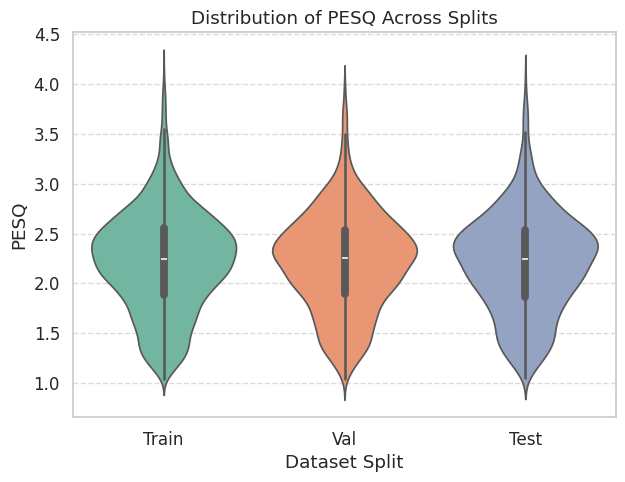

Plotting STOI...
Saved: metric_plots/plot_STOI.png


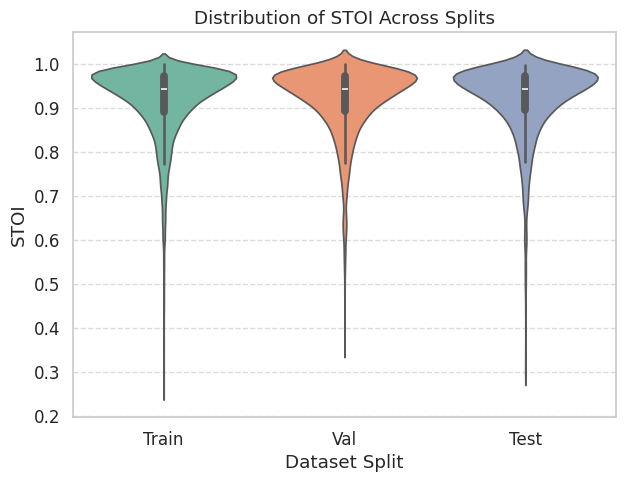

Plotting SI-SDR (dB)...
Saved: metric_plots/plot_SI_SDR_dB.png


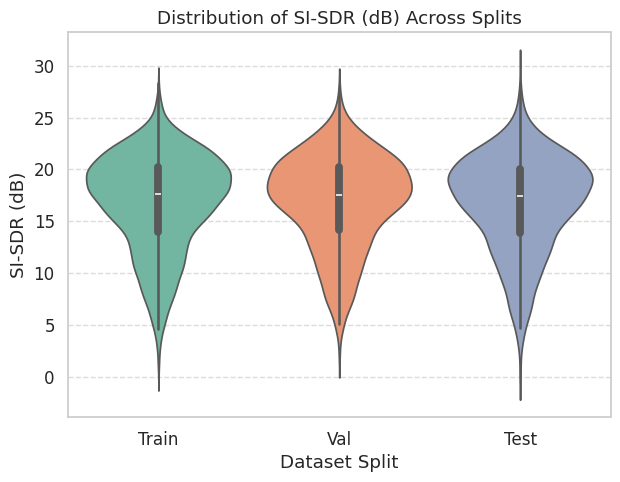

--- Finished generating separate plots ---


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os # Import os module to handle file paths


if 'full_df' not in locals(): # Basic check if data exists
    print("Generating placeholder data...")
    train_ps, val_ps, test_ps = np.random.rand(50)*2+1.5, np.random.rand(20)*2+1.6, np.random.rand(30)*2+1.4
    train_st, val_st, test_st = np.random.rand(50)*0.2+0.75, np.random.rand(20)*0.2+0.78, np.random.rand(30)*0.2+0.72
    train_sd, val_sd, test_sd = np.random.rand(50)*5+12, np.random.rand(20)*5+13, np.random.rand(30)*5+11

    def build_metric_df(metric_list, metric_name):
        return pd.DataFrame({
            "Score": np.concatenate(metric_list), # Use concatenate for numpy arrays
            "Split": ["Train"] * len(metric_list[0]) +
                     ["Val"] * len(metric_list[1]) +
                     ["Test"] * len(metric_list[2]),
            "Metric": metric_name
        })

    df_pesq  = build_metric_df([train_ps, val_ps, test_ps], "PESQ")
    df_stoi  = build_metric_df([train_st, val_st, test_st], "STOI")
    df_sisdr = build_metric_df([train_sd, val_sd, test_sd], "SI-SDR (dB)")

    full_df = pd.concat([df_pesq, df_stoi, df_sisdr], ignore_index=True)

# --- Plotting Separately ---
sns.set(style="whitegrid", font_scale=1.1)
dataset_order = ['Train', 'Val', 'Test']
palette = "Set2"

metric_names = full_df['Metric'].unique()

# Create a directory to save plots (optional)
output_dir = "metric_plots"
os.makedirs(output_dir, exist_ok=True)

print(f"--- Generating and saving separate plots to '{output_dir}' directory ---")

for metric_name in metric_names:
    print(f"Plotting {metric_name}...")

    # Filter the DataFrame for the current metric
    metric_df = full_df[full_df['Metric'] == metric_name]

    # Create a new figure and axes for each plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # Create the violin plot on the current axes
    sns.violinplot(
        data=metric_df,
        x="Split",
        y="Score",
        hue="Split",
        order=dataset_order,
        palette=palette,
        inner="box",
        ax=ax
    )

    # --- Customization for the current plot ---
    ax.set_title(f"Distribution of {metric_name} Across Splits")
    ax.set_xlabel("Dataset Split")
    ax.set_ylabel(metric_name) # Use metric name as y-label
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Save the current figure ---
    safe_metric_name = metric_name.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('-', '_')
    filename = os.path.join(output_dir, f"plot_{safe_metric_name}.png")

    try:
        fig.savefig(filename, bbox_inches='tight', dpi=150)
        print(f"Saved: {filename}")
    except Exception as e:
        print(f"Error saving {filename}: {e}")


    # Close the figure to free memory before the next iteration
    plt.show()
    plt.close(fig)

print("--- Finished generating separate plots ---")

### Visualise + listen to one test‑set example

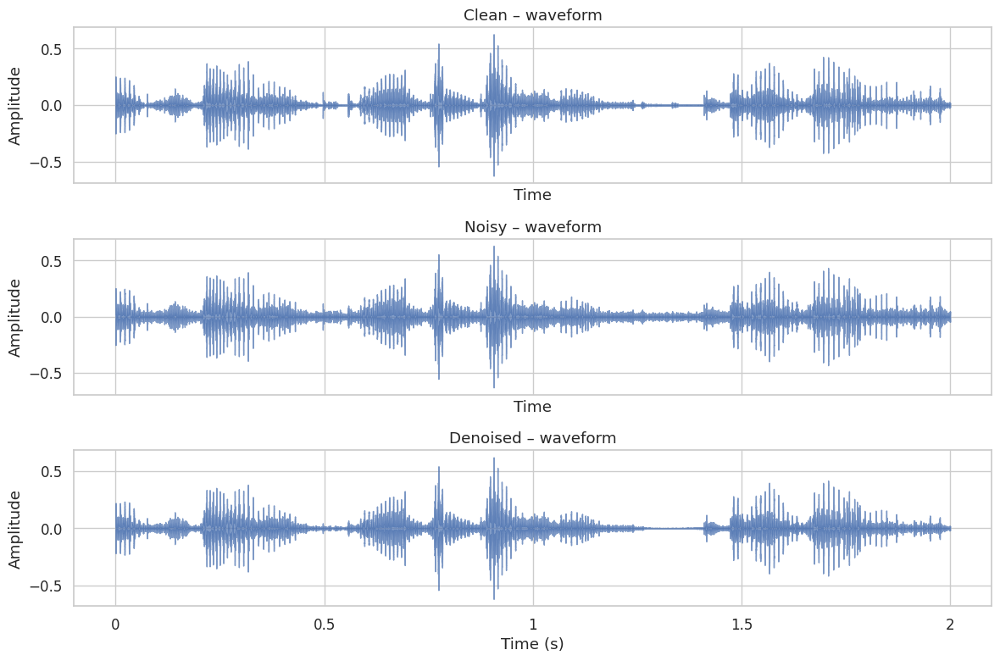

<ipython-input-74-9a15d0c20f99>:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


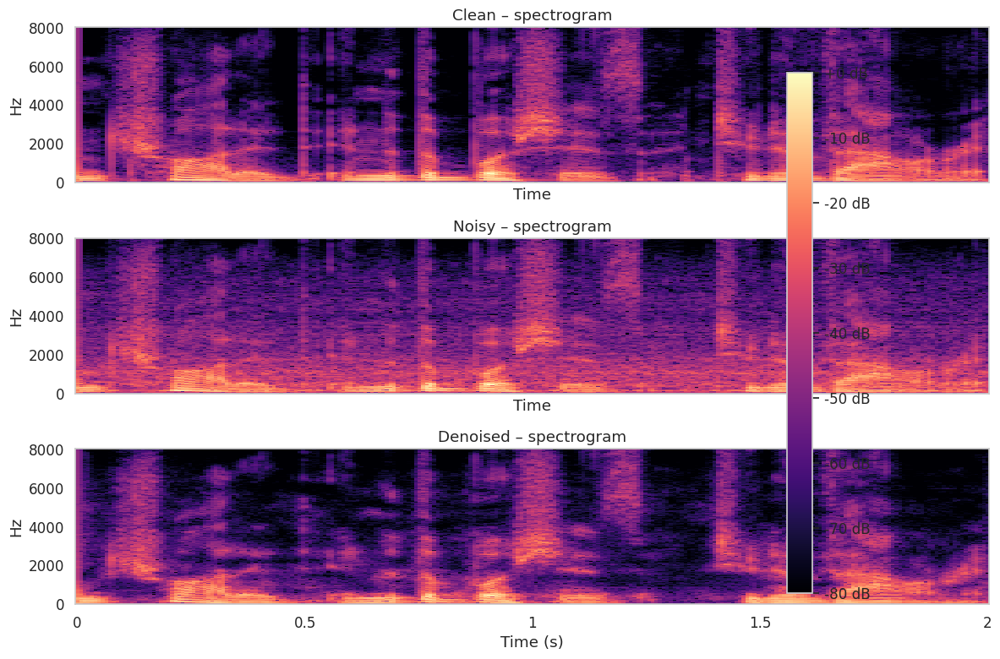

▶ Clean


▶ Noisy


▶ Denoised


In [ ]:
import random, numpy as np, matplotlib.pyplot as plt, librosa, librosa.display
from IPython.display import Audio, display

test_ds = SegDataset(MANIFEST, "test", Cfg)
idx      = 0
row      = test_ds.meta.iloc[idx]
clean_wav, _ = librosa.load(row.clean, sr=Cfg.sr)
noisy_wav, _ = librosa.load(row.noisy, sr=Cfg.sr)

# 2⃣  Denoise
with torch.no_grad():
    nm = test_ds[idx]["nm"].unsqueeze(0).to(device)
    out = net(nm).cpu()[0,0].numpy()

logmag_pred = out * (test_ds.gmax - test_ds.gmin) + test_ds.gmin
mag_pred    = np.expm1(logmag_pred)
phase       = np.angle(librosa.stft(noisy_wav,
                                    n_fft=Cfg.n_fft,
                                    hop_length=Cfg.hop,
                                    win_length=Cfg.win))
denoised_wav = librosa.istft(mag_pred * np.exp(1j*phase),
                             hop_length=Cfg.hop,
                             win_length=Cfg.win,
                             length=len(clean_wav))



# 1️⃣ Three waveforms in one figure
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, y, title in zip(axes,
                       [clean_wav, noisy_wav, denoised_wav],
                       ["Clean", "Noisy", "Denoised"]):
    librosa.display.waveshow(y, sr=Cfg.sr, ax=ax, alpha=0.7)
    ax.set(title=f"{title} – waveform",
           ylabel="Amplitude")
axes[-1].set(xlabel="Time (s)")
fig.tight_layout()
plt.show()

# 2️⃣ Three spectrograms in one figure
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, sharey=True)
for ax, y, title in zip(axes,
                       [clean_wav, noisy_wav, denoised_wav],
                       ["Clean", "Noisy", "Denoised"]):
    D = librosa.amplitude_to_db(
          np.abs(librosa.stft(y, n_fft=512, hop_length=128)),
          ref=np.max)
    img = librosa.display.specshow(D,
                                   sr=Cfg.sr,
                                   hop_length=128,
                                   x_axis="time",
                                   y_axis="linear",
                                   ax=ax)
    ax.set(title=f"{title} – spectrogram")
# put a single colorbar on the right
fig.colorbar(img, ax=axes, format="%+2.0f dB")
axes[-1].set(xlabel="Time (s)")
fig.tight_layout()
plt.show()

print("▶ Clean");    display(Audio(clean_wav,    rate=Cfg.sr))
print("▶ Noisy");    display(Audio(noisy_wav,    rate=Cfg.sr))
print("▶ Denoised"); display(Audio(denoised_wav, rate=Cfg.sr))
